# Multiple Linear Regression with Car Data
Machine Learning Club, Meeting 1 (Live Code-Along)

Can weight and horsepower help us estimate a car's fuel efficiency? We will fit an ordinary least squares (OLS) model to 32 cars from the `mtcars` dataset, then look at its coefficients, predictions, and residuals.

## Data

Each row represents one car. We will use `weight_1000_lbs` (weight in thousands of pounds) and `horsepower` to predict `mpg` (US miles per gallon). The cars come from 1974 *Motor Trend* road tests. [Dataset documentation](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/mtcars.html) and local CSV: `real_cars_linear_regression.csv`.

This small historical dataset is useful for learning the workflow. It is not enough to validate a fuel-economy model for modern cars.

## The scikit-learn pattern

Many scikit-learn models use the same three calls:

```python
model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)
```

## 1. Load the data

Read the CSV into arrays for weight, horsepower, and MPG. Each array has one value per car.

In [7]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

with open('real_cars_linear_regression.csv', newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

weight = np.array([float(row['weight_1000_lbs']) for row in rows])
horsepower = np.array([float(row['horsepower']) for row in rows])
mpg = np.array([float(row['mpg']) for row in rows])

print(f"Loaded {len(rows)} cars.")
print("First row:", rows[0])

Loaded 32 cars.
First row: {'car_model': 'Mazda RX4', 'horsepower': '110', 'weight_1000_lbs': '2.620', 'mpg': '21.0'}


## 2. Explore the data

The two inputs, weight and horsepower, are on the horizontal axes. MPG is on the vertical axis. As cars get heavier or more powerful, what happens to their MPG?

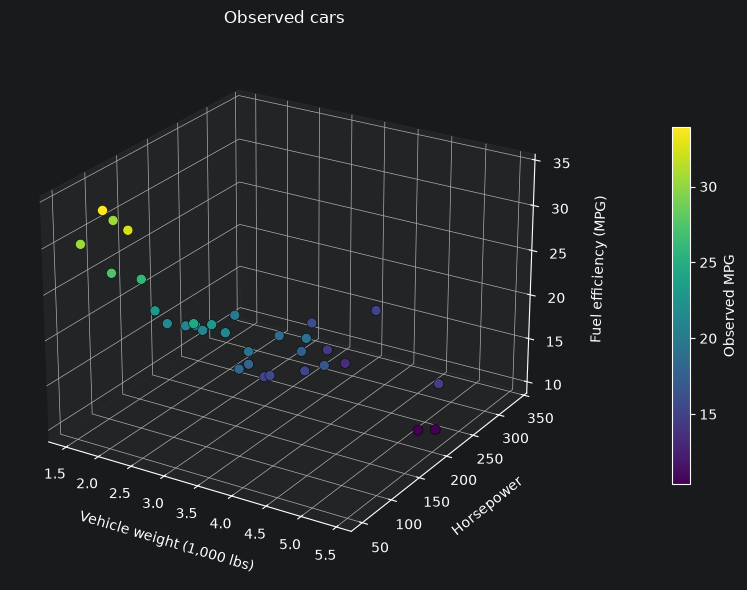

In [8]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
points = ax.scatter(weight, horsepower, mpg, c=mpg, cmap='viridis',
                    s=52, edgecolor='black', linewidth=0.35, depthshade=False)
ax.set_xlabel('Vehicle weight (1,000 lbs)', labelpad=9)
ax.set_ylabel('Horsepower', labelpad=9)
ax.set_zlabel('Fuel efficiency (MPG)', labelpad=9)
ax.set_title('Observed cars')
ax.view_init(elev=24, azim=-58)
fig.colorbar(points, ax=ax, shrink=0.65, pad=0.13, label='Observed MPG')
plt.tight_layout()
plt.show()

## 3. Fit an OLS model

For each car, we model MPG as a linear combination of weight and horsepower:

$$\hat y = \beta_0 + \beta_1(\text{weight}) + \beta_2(\text{horsepower})$$

Here $\hat y$ is predicted MPG, $\beta_0$ is the intercept, and $\beta_1$ and $\beta_2$ are the coefficients for weight and horsepower. OLS chooses these values to minimize the sum of squared differences between observed and predicted MPG:

$$\text{SSE} = \sum_{i=1}^{n}(y_i-\hat y_i)^2$$

This is the same objective we solve in the mathematical derivation. In code, `LinearRegression.fit(X, y)` finds the coefficients for us.

### Shape of the inputs

`weight` and `horsepower` each have shape `(32,)`. `np.column_stack([weight, horsepower])` makes `X` with shape `(32, 2)`: one car per row, with weight in the first column and horsepower in the second. The target array `y` has shape `(32,)`.

### The intercept

In the matrix derivation, we add a column of ones so that $\tilde X_i=[1,\text{weight}_i,\text{horsepower}_i]$ and the intercept can be part of $\beta$. The `X` we pass to scikit-learn contains only the two measured features. `LinearRegression` fits the intercept by default and stores the result in `model.intercept_`; the other coefficients are in `model.coef_`.

In [13]:
# TODO 1: Build X with one row per car and columns for weight and horsepower.
X = ...

# TODO 2: Set y to the MPG values we want to predict.
y = ...

print(f"X shape: {X.shape}; y shape: {y.shape}")

# TODO 3: Create a linear-regression model.
model = ...

# TODO 4: Fit the model to X and y.
...

# TODO 5: Predict MPG for every car in X.
predicted_mpg = ...

mse = mean_squared_error(y, predicted_mpg)
r_squared = r2_score(y, predicted_mpg)

print("\nCoefficients")
print(f"Intercept:  {model.intercept_:.3f} MPG")
print(f"Weight:     {model.coef_[0]:.3f} MPG per 1,000 lbs")
print(f"Horsepower: {model.coef_[1]:.4f} MPG per hp")
print("\nFit on the same 32 cars")
print(f"MSE:  {mse:.3f} (MPG)^2")
print(f"RMSE: {np.sqrt(mse):.3f} MPG")
print(f"R^2:  {r_squared:.3f}")

AttributeError: 'ellipsis' object has no attribute 'shape'

### Reading the results

The weight coefficient is about $-3.878$: at the same horsepower, 1,000 more pounds corresponds to 3.88 lower *predicted* MPG. The horsepower coefficient is about $-0.0318$: at the same weight, 10 more horsepower corresponds to 0.32 lower predicted MPG. These describe the fitted relationship, not the effect of changing one feature on a real car.

The intercept is 37.227 MPG, the model's prediction at zero weight and zero horsepower. That is outside the range of real cars, so it has no practical interpretation here.

The mean squared error (MSE) is the sum of squared residuals divided by 32: $6.095\,(\text{MPG})^2$. Its square root, RMSE, is $2.469\text{ MPG}$. RMSE puts more weight on large misses and is not an average absolute error or a guaranteed error range.

$R^2=0.827$ means the model accounts for about 82.7% of the MPG variation in these 32 cars relative to predicting their mean. All three scores use the same cars that were used to fit the model. They describe this fit, not accuracy on other cars.

## 4. Predict MPG for another car

Suppose a car weighs 3,200 pounds and has 165 horsepower. Since weight is measured in thousands of pounds, its input row is `[3.2, 165]`. Scikit-learn expects a 2D array even for one car, so we pass `[[3.2, 165]]`.

We do not know this car's actual MPG. The result is a prediction, not an accuracy check.

In [12]:
# TODO: Create a two-dimensional input row for a 3,200 lb, 165 hp car.
new_car = ...

# TODO: Predict its MPG and select the one result.
predicted_value = ...

manual_calc = model.intercept_ + model.coef_[0] * 3.2 + model.coef_[1] * 165
print(f"Predicted MPG: {predicted_value:.2f}")
print(f"From the equation: {manual_calc:.2f}")

TypeError: unsupported format string passed to ellipsis.__format__

## 5. Plot the fit and residuals

With one feature, a linear fit is a line. With two features, it is a plane. Each orange segment connects a car's observed MPG to the plane at that car's weight and horsepower. OLS minimizes the sum of these vertical differences squared, not the shortest geometric distances to the plane.

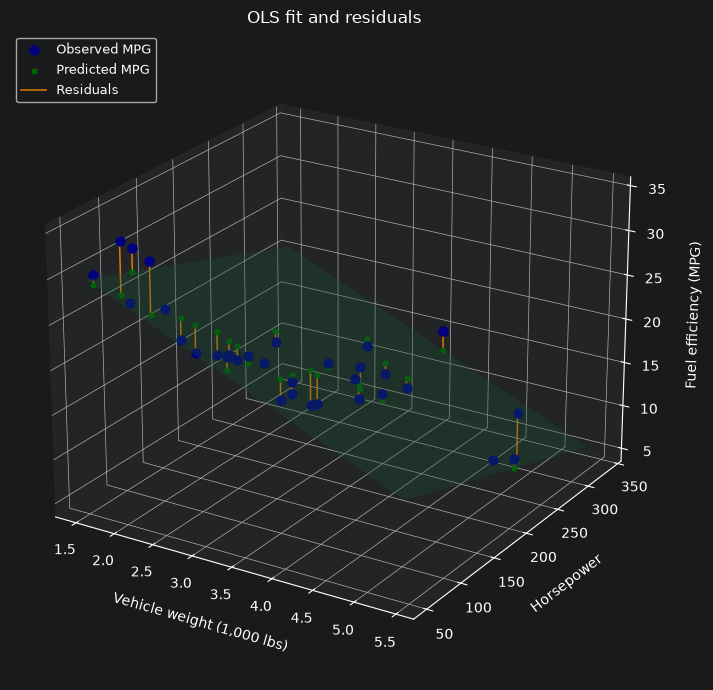

In [11]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Build a grid of weight and horsepower values
w_grid = np.linspace(weight.min(), weight.max(), 30)
hp_grid = np.linspace(horsepower.min(), horsepower.max(), 30)
W, H = np.meshgrid(w_grid, hp_grid)

# Predict MPG across the grid
grid_points = np.column_stack([W.ravel(), H.ravel()])
MPG_plane = model.predict(grid_points).reshape(W.shape)

ax.plot_surface(W, H, MPG_plane, color='mediumseagreen', alpha=0.32,
                linewidth=0, antialiased=True)
ax.scatter(weight, horsepower, mpg, color='navy', s=42,
           label='Observed MPG', depthshade=False)
ax.scatter(weight, horsepower, predicted_mpg, color='darkgreen', s=12,
           label='Predicted MPG', depthshade=False)

# Residuals keep weight and horsepower fixed
for i, (wi, hi, actual, predicted) in enumerate(zip(weight, horsepower, mpg, predicted_mpg)):
    ax.plot([wi, wi], [hi, hi], [predicted, actual],
            color='darkorange', linewidth=1.1, alpha=0.85,
            label='Residuals' if i == 0 else None)

ax.set_xlabel('Vehicle weight (1,000 lbs)', labelpad=9)
ax.set_ylabel('Horsepower', labelpad=9)
ax.set_zlabel('Fuel efficiency (MPG)', labelpad=9)
ax.set_title('OLS fit and residuals')
ax.view_init(elev=23, azim=-58)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()